<a href="https://colab.research.google.com/github/chenuli949/AI-movie-review-analysis/blob/Ruchith/05_BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bi Directional LSTM for IMDb Movie Review Sentiment Analysis


In [3]:
!git clone https://github.com/chenuli949/AI-movie-review-analysis.git

fatal: destination path 'AI-movie-review-analysis' already exists and is not an empty directory.


In [4]:
%cd AI-movie-review-analysis

/content/AI-movie-review-analysis


In [5]:
!ls data

processed_imdb_reviews.csv  train_indices.npy
test_indices.npy	    validation_indices.npy


In [6]:
import os, time, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, matthews_corrcoef)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus)
HARDWARE = "GPU" if gpus else "CPU (no GPU)"

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random seed: 42


## 1. Load data and the shared split indices

In [7]:
df = pd.read_csv("data/processed_imdb_reviews.csv")
train_idx = np.load("data/train_indices.npy")
val_idx   = np.load("data/validation_indices.npy")
test_idx  = np.load("data/test_indices.npy")

X = df["clean_review"].values
y = df["label"].values
X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train/Val/Test:", len(X_train), len(X_val), len(X_test))
print("Disjoint & complete:", len(np.unique(np.concatenate([train_idx, val_idx, test_idx]))) == len(df))
print("Train labels:", np.bincount(y_train), "| Val:", np.bincount(y_val), "| Test:", np.bincount(y_test))

Train/Val/Test: 40000 5000 5000
Disjoint & complete: True
Train labels: [20000 20000] | Val: [2500 2500] | Test: [2500 2500]


## 2. Vectorization

In [8]:
VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 300
EMBEDDING_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 10

vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_mode="int",
                               output_sequence_length=MAX_SEQUENCE_LENGTH)
vectorizer.adapt(X_train)
print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Vocabulary size: 20000


## 3. Building the Bi-LSTM model


In [9]:
model = models.Sequential([
    layers.Input(shape=(), dtype=tf.string),
    vectorizer,
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
    layers.Bidirectional(layers.LSTM(LSTM_UNITS)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="bilstm")

model.summary()
print("Total parameters:", model.count_params())

Model: "bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,839,681 (10.83 MB)

 Trainable params: 2,839,681 (10.83 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 2839681


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2,
                                                  restore_best_weights=True)

class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t)
timer = EpochTimer()

## 4. Train

In [11]:
start = time.time()
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[early_stopping, timer], verbose=1)
training_time = time.time() - start

epochs_run = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nTraining time: {training_time:.2f} s | epochs run: {epochs_run} | best epoch: {best_epoch}")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.8217 - loss: 0.3872 - precision: 0.8297 - recall: 0.8095 - val_accuracy: 0.8704 - val_loss: 0.3108 - val_precision: 0.9360 - val_recall: 0.7952
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9197 - loss: 0.2054 - precision: 0.9181 - recall: 0.9215 - val_accuracy: 0.8702 - val_loss: 0.3317 - val_precision: 0.9145 - val_recall: 0.8168
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9425 - loss: 0.1526 - precision: 0.9385 - recall: 0.9471 - val_accuracy: 0.8748 - val_loss: 0.3518 - val_precision: 0.8834 - val_recall: 0.8636

Training time: 74.55 s | epochs run: 3 | best epoch: 1


In [12]:

history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", range(1, epochs_run + 1))
history_df["time_s"] = np.round(timer.times, 1)
history_df

,epoch,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,time_s
0,1,0.821650,0.387168,0.829661,0.80950,0.8704,0.310792,0.935970,0.7952,28.4
1,2,0.919650,0.205397,0.918103,0.92150,0.8702,0.331687,0.914465,0.8168,23.2
2,3,0.942525,0.152568,0.938469,0.94715,0.8748,0.351822,0.883388,0.8636,22.8


## 5. Learning curves

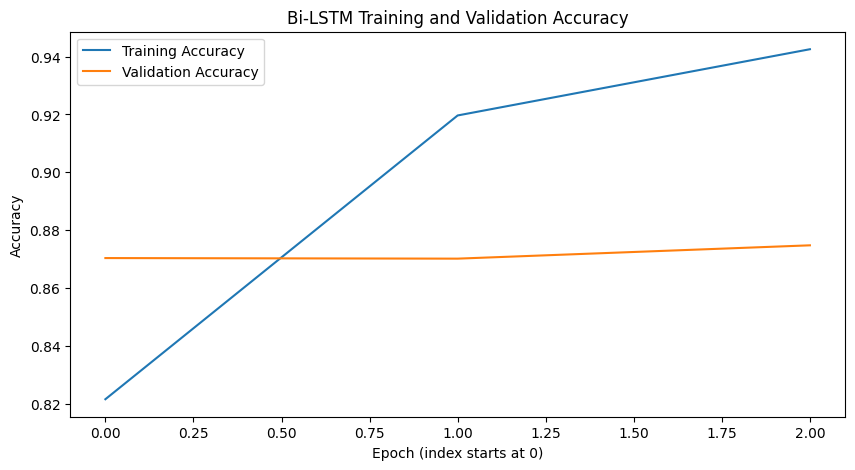

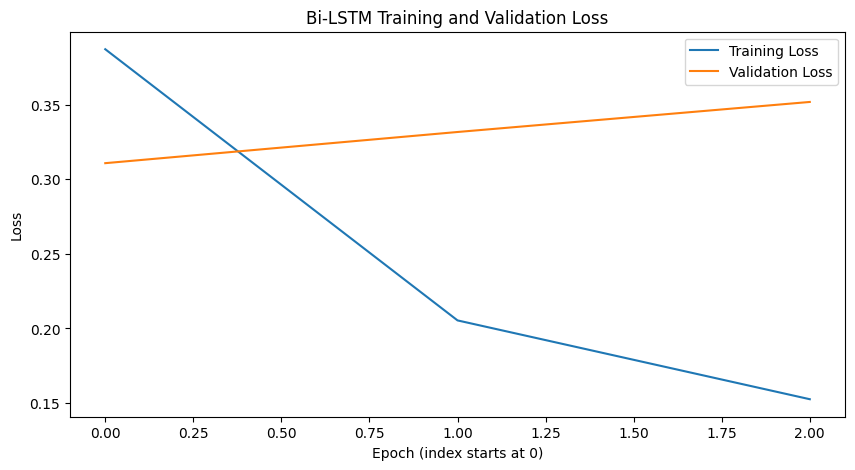

In [13]:
os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/predictions", exist_ok=True)
os.makedirs("models", exist_ok=True)

for key, title, fname in [("accuracy", "Accuracy", "bilstm_accuracy"), ("loss", "Loss", "bilstm_loss")]:
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[key], label=f"Training {title}")
    plt.plot(history.history["val_" + key], label=f"Validation {title}")
    plt.title(f"Bi-LSTM Training and Validation {title}")
    plt.xlabel("Epoch (index starts at 0)"); plt.ylabel(title); plt.legend()
    plt.savefig(f"results/figures/{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Test-set evaluation (run once, after training)

In [14]:
test_loss = model.evaluate(X_test, y_test, verbose=0)[0]

t0 = time.time()
y_prob = model.predict(X_test, verbose=0).ravel()
inference_time = time.time() - t0
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
mcc  = matthews_corrcoef(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)
fpr_rate, fnr_rate = fp / (fp + tn), fn / (fn + tp)

n = len(y_test)
ci = 1.96 * math.sqrt(acc * (1 - acc) / n)
val_acc_selected = history.history["val_accuracy"][best_epoch - 1]

print("Bi-LSTM TEST RESULTS")
print("=" * 50)
print(f"Test loss           : {test_loss:.4f}")
print(f"Accuracy            : {acc:.4f}  (95% CI {acc-ci:.4f} - {acc+ci:.4f})")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"ROC-AUC             : {auc:.4f}")
print(f"Specificity         : {specificity:.4f}")
print(f"FPR / FNR           : {fpr_rate:.4f} / {fnr_rate:.4f}")
print(f"MCC                 : {mcc:.4f}")
print(f"TN / FP / FN / TP   : {tn:,} / {fp:,} / {fn:,} / {tp:,}")
print(f"Val acc (best ep.)  : {val_acc_selected:.4f}")
print(f"Inference (5,000)   : {inference_time:.2f} s")
print()
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Bi-LSTM TEST RESULTS
Test loss           : 0.3331
Accuracy            : 0.8574  (95% CI 0.8477 - 0.8671)
Precision           : 0.9323
Recall              : 0.7708
F1-score            : 0.8439
ROC-AUC             : 0.9512
Specificity         : 0.9440
FPR / FNR           : 0.0560 / 0.2292
MCC                 : 0.7258
TN / FP / FN / TP   : 2,360 / 140 / 573 / 1,927
Val acc (best ep.)  : 0.8704
Inference (5,000)   : 2.28 s

              precision    recall  f1-score   support

    Negative       0.80      0.94      0.87      2500
    Positive       0.93      0.77      0.84      2500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



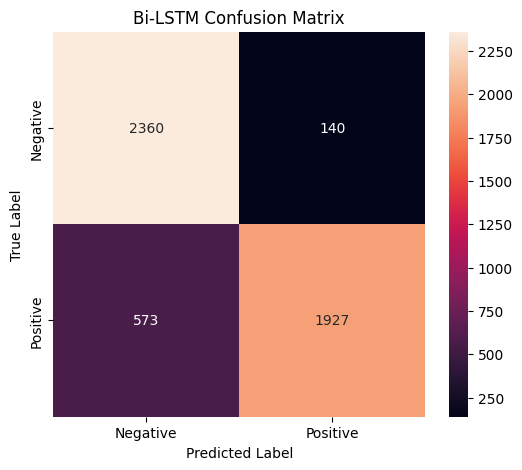

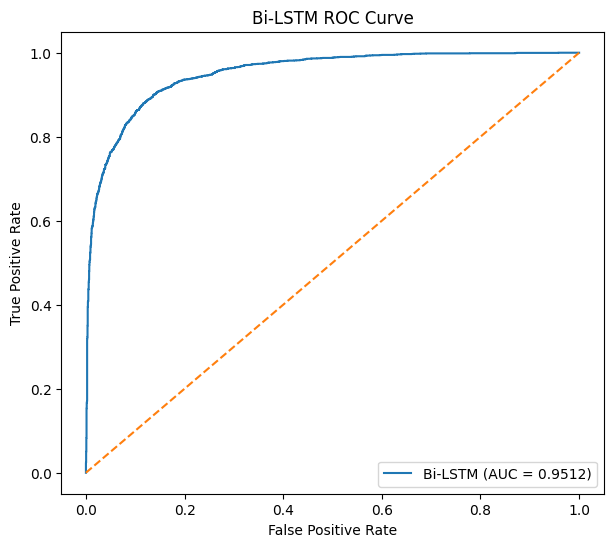

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Bi-LSTM Confusion Matrix"); plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.savefig("results/figures/bilstm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr_c, tpr_c, label=f"Bi-LSTM (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Bi-LSTM ROC Curve"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend()
plt.savefig("results/figures/bilstm_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Error analysis

In [16]:
# (a) truncation test: error rate for reviews <= 300 words vs > 300 words
words = np.array([len(str(t).split()) for t in X_test])
wrong = (y_pred != y_test)
short, long_ = words <= 300, words > 300
print(f"Reviews <= 300 words: {short.sum():,} | error rate {wrong[short].mean():.4f}")
print(f"Reviews  > 300 words: {long_.sum():,} | error rate {wrong[long_].mean():.4f}")
print(f"False negatives among > 300 words: {int(((y_test==1)&(y_pred==0)&long_).sum())} of {fn}")

# (b) example errors with probabilities
def show(mask, order, title, k=3):
    idx = np.where(mask)[0]
    idx = idx[np.argsort(y_prob[idx])] if order == "asc" else idx[np.argsort(-y_prob[idx])]
    print(f"\n=== {title} ===")
    for i in idx[:k]:
        print(f"P(positive)={y_prob[i]:.3f} | words={words[i]} | {X_test[i][:350]}...\n")

show((y_test == 1) & (y_pred == 0), "asc",  "Most confident FALSE NEGATIVES")
show((y_test == 0) & (y_pred == 1), "desc", "Most confident FALSE POSITIVES")

Reviews <= 300 words: 3,937 | error rate 0.1280
Reviews  > 300 words: 1,063 | error rate 0.1966
False negatives among > 300 words: 179 of 573

=== Most confident FALSE NEGATIVES ===
P(positive)=0.003 | words=47 | Ernest Borgnine was so wasted in this movie.There was no point in putting this great actor in this movie.One of the greatest actors in the world wasted,and for what reason, none what so ever,so america if you want to put classic actors in movies DON'T WASTE THEM...

P(positive)=0.006 | words=123 | Okay, first of all I got this movie as a Christmas present so it was FREE! FIRST - This movie was meant to be in stereoscopic 3D. It is for the most part, but whenever the main character is in her car the movie falls flat to 2D! What!!?!?! It's not that hard to film in a car!!! SECOND - The story isn't very good. There are a lot of things wrong wit...

P(positive)=0.006 | words=105 | This flick is sterling example of the state of erotic B-movies: bad porn movies without the hardcore 

## 8.Metrics, predictions and model

In [17]:
results = pd.DataFrame({
    "Model": ["BiLSTM"], "Accuracy": [acc], "CI_low": [acc-ci], "CI_high": [acc+ci],
    "Precision": [prec], "Recall": [rec], "F1": [f1], "ROC_AUC": [auc], "MCC": [mcc],
    "Specificity": [specificity], "FPR": [fpr_rate], "FNR": [fnr_rate],
    "TN": [tn], "FP": [fp], "FN": [fn], "TP": [tp],
    "Test_Loss": [test_loss], "Val_Accuracy_Selected": [val_acc_selected],
    "Training_Time_Seconds": [training_time], "Epochs_Run": [epochs_run], "Best_Epoch": [best_epoch],
    "Avg_Time_Per_Epoch_s": [float(np.mean(timer.times))], "Inference_5000_s": [inference_time],
    "Parameters": [model.count_params()], "Hardware": [HARDWARE]})
results.to_csv("results/metrics/bilstm_results.csv", index=False)
history_df.to_csv("results/metrics/bilstm_history.csv", index=False)


np.save("results/predictions/bilstm_test_probs.npy", y_prob)
model.save("models/bilstm_imdb.keras")
results.T

,0
Model,BiLSTM
Accuracy,0.8574
CI_low,0.847708
CI_high,0.867092
Precision,0.932269
Recall,0.7708
F1,0.84388
ROC_AUC,0.951214
MCC,0.725769
Specificity,0.944


### Final summary

In [19]:
print("===== Bi-LSTM EXPERIMENT SUMMARY =====")
print(f"Train/Val/Test   : {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Vocab / SeqLen / Emb : {VOCAB_SIZE} / {MAX_SEQUENCE_LENGTH} / {EMBEDDING_DIM}")
print(f"Accuracy {acc:.4f} | Precision {prec:.4f} | Recall {rec:.4f} | F1 {f1:.4f} | AUC {auc:.4f}")
print(f"Training time {training_time:.2f}s | Parameters {model.count_params():,} | Hardware {HARDWARE}")

===== Bi-LSTM EXPERIMENT SUMMARY =====
Train/Val/Test   : 40000 / 5000 / 5000
Vocab / SeqLen / Emb : 20000 / 300 / 128
Accuracy 0.8574 | Precision 0.9323 | Recall 0.7708 | F1 0.8439 | AUC 0.9512
Training time 74.55s | Parameters 2,839,681 | Hardware GPU
